# Actividad del departamento: ventas, pedidos y vendedoras activas

**Ninguna variante de actividad superó el AUC mensual de la base (0.790383).** La mejor variante de actividad por esa métrica fue **Base + comparación a 6 y 12 meses** (0.789922, delta -0.000461). Las diferencias en detección al top 10 % se muestran por separado y no justifican por sí solas sustituir el modelo.

Este notebook lee resultados guardados, sin reentrenar ni ejecutar Optuna. [Informe con variables y definiciones](../07_results/ablacion_actividad_departamental.md).

La variante de **seis meses** detectó **301** casos frente a **295** entre las mismas **431** observaciones priorizadas al top 10 %. La precisión pasó de **68,45 % a 69,84 %** (+1,39 puntos porcentuales). Mejoró el conteo en 7 de los 16 meses, empeoró en 2 y empató en 7. En el top 20 %, en cambio, detectó 541 frente a 546. Por tanto, el beneficio observado se limita al grupo de mayor riesgo y requiere confirmación independiente; no implica una mejora general de discriminación. Combinar seis y doce meses también detectó 301 casos en el top 10 %, añadiendo más columnas.



In [1]:
from pathlib import Path
import json
import hashlib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'scripts/regional_activity_ablation.py').exists())
OUT = ROOT / 'reports/regional_activity_v1'
protocol = json.loads((OUT / 'protocol.json').read_text())
for relative, expected in protocol['sources'].items():
    assert hashlib.sha256((ROOT / relative).read_bytes()).hexdigest() == expected
comparison = pd.read_csv(OUT / 'comparison.csv')
monthly = pd.read_csv(OUT / 'monthly_metrics.csv')
blocks = pd.read_csv(OUT / 'block_metrics.csv')
components = pd.read_csv(OUT / 'component_metrics.csv')
print('Fuentes intactas. Ventanas:', protocol['window'])

Fuentes intactas. Ventanas: mean of 3 complete months; endpoints t-1, t-7, t-13


## Evaluación comparable

Se mantienen los parámetros del ensemble, 50/50, las 42 variables originales, cuatro bloques temporales y 4.379 filas. El código del departamento es un control adicional; las demás variantes contienen contexto numérico. Esta evaluación de desarrollo no es la prueba OOT final independiente.

In [2]:
display(comparison[['variant','auc_mean','auc_monthly_mean','delta_auc_monthly_mean','tp_top10','tp_top20','ap_mean']].round(6))
display(pd.read_csv(OUT / 'coverage.csv'))

,variant,auc_mean,auc_monthly_mean,delta_auc_monthly_mean,tp_top10,tp_top20,ap_mean
0,transaccional,0.789880,0.790383,0.000000,295,546,0.596209
1,mas_departamento,0.788920,0.789691,-0.000692,292,537,0.587713
2,actividad_reciente,0.789204,0.789670,-0.000713,297,542,0.592562
3,actividad_6m,0.789461,0.789904,-0.000479,301,541,0.594935
4,actividad_12m,0.789287,0.789716,-0.000667,294,544,0.592687
5,actividad_6m_12m,0.789446,0.789922,-0.000461,301,542,0.594796


,partition,rows,missing_department,missing_window_h0,missing_window_h6,missing_window_h12
0,development,28311,70,1085,3935,6650
1,validation,4379,3,3,3,3


## Estabilidad mensual

fold,0,1,2,3
variant,,,,
actividad_12m,0.785089,0.794549,0.780246,0.797263
actividad_6m,0.784894,0.794978,0.779927,0.798045
actividad_6m_12m,0.784915,0.795396,0.779742,0.797730
actividad_reciente,0.785170,0.793766,0.780637,0.797242
mas_departamento,0.785685,0.792243,0.782556,0.795196
transaccional,0.785349,0.794934,0.781867,0.797368


variant
actividad_12m         6
actividad_6m          6
actividad_6m_12m      8
actividad_reciente    3
mas_departamento      6
Name: Meses superiores a base (de 16), dtype: int64

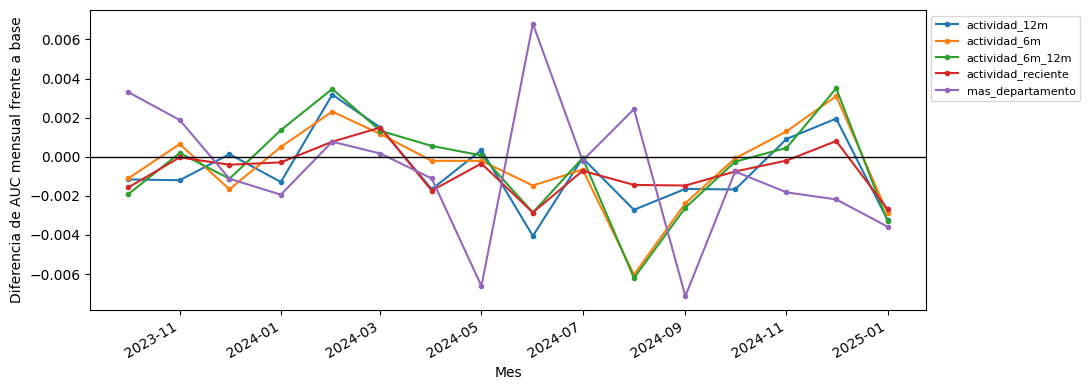

In [3]:
display(blocks.pivot(index='variant',columns='fold',values='auc').round(6))
ma = monthly.loc[monthly.top_fraction.eq(.1)].pivot(index='month',columns='variant',values='auc')
delta = ma.subtract(ma.transaccional,axis=0).drop(columns='transaccional')
display(delta.gt(0).sum().rename('Meses superiores a base (de 16)'))
fig, ax = plt.subplots(figsize=(11,4))
for name in delta:
    ax.plot(pd.to_datetime(delta.index),delta[name],marker='o',markersize=3,label=name)
ax.axhline(0,color='black',linewidth=1)
ax.set(ylabel='Diferencia de AUC mensual frente a base',xlabel='Mes')
ax.legend(fontsize=8,loc='upper left',bbox_to_anchor=(1,1))
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## Logística y XGBoost por separado

In [4]:
display(components[['variant','model','auc_mean','auc_monthly_mean','tp_top10']].round(6))

,variant,model,auc_mean,auc_monthly_mean,tp_top10
0,transaccional,logreg,0.787625,0.787839,293
1,transaccional,xgboost,0.788335,0.789059,298
2,mas_departamento,logreg,0.785820,0.786509,291
3,mas_departamento,xgboost,0.788146,0.788888,296
4,actividad_reciente,logreg,0.787017,0.787462,295
5,actividad_reciente,xgboost,0.788151,0.789044,296
6,actividad_6m,logreg,0.787554,0.787997,292
7,actividad_6m,xgboost,0.787918,0.788729,297
8,actividad_12m,logreg,0.786815,0.787336,291
9,actividad_12m,xgboost,0.788018,0.788691,297


## Ejemplo de enero de 2025

Promedios departamentales de octubre–diciembre de 2024 y variaciones porcentuales contra el mismo trimestre de 2023. Esta tabla incluye todas las vendedoras; el modelo descuenta la contribución individual.

In [5]:
display(pd.read_csv(OUT / 'department_example_jan2025.csv').head(8).round(2))
variables = json.loads((OUT / 'variables.json').read_text())
display(pd.DataFrame([{'variant':k,'n_columnas_numericas':len(v),'variables':', '.join(v)} for k,v in variables['variants'].items()]))

,department_key,mean3_monto,mean3_n_ped,mean3_activo,sales_change_pct_12m,active_change_pct_12m
0,lima,36874.36,99.67,74.67,-42.65,-26.07
1,piura,12563.87,31.00,26.33,-10.04,-13.19
2,ancash,12408.70,28.67,24.00,-44.82,-34.55
3,ica,9664.96,23.33,17.00,-4.26,-10.53
4,la libertad,8683.78,23.67,22.33,-24.94,-17.28
5,loreto,7359.64,16.33,13.67,-32.06,-26.79
6,arequipa,7115.32,20.67,16.67,-37.58,-19.35
7,junin,6971.43,19.33,14.33,-23.17,-28.33


,variant,n_columnas_numericas,variables
0,transaccional,0,
1,mas_departamento,0,
2,actividad_reciente,4,"regional_log_ventas_h0, regional_log_pedidos_h..."
3,actividad_6m,11,"regional_log_ventas_h0, regional_log_pedidos_h..."
4,actividad_12m,11,"regional_log_ventas_h0, regional_log_pedidos_h..."
5,actividad_6m_12m,18,"regional_log_ventas_h0, regional_log_pedidos_h..."


## Alcance temporal y limitaciones

- Se conserva el protocolo temporal de desarrollo: cuatro bloques de cuatro meses (octubre 2023–enero 2025), gap de seis meses, 4.379 observaciones vendedora–mes y 16 meses de validación. Es validación reutilizada para seleccionar variables, **no el OOT final independiente**.
- La logística usa los últimos 36 meses permitidos y XGBoost la historia permitida completa; el ensemble mantiene 50/50 y los hiperparámetros exportados. No se ejecuta Optuna ni se buscan ventanas o umbrales a partir de la validación.
- Para la observación de mes `t`, la fecha máxima de información regional es `t−1`. Por ejemplo, para enero de 2025, la actividad reciente promedia octubre–diciembre de 2024; seis meses antes, abril–junio de 2024; doce meses antes, octubre–diciembre de 2023.
- La fuente es el panel mensual completo, incluyendo vendedoras nuevas y primeras compras. No se suman ventanas móviles del dataset de churn, que duplicarían ventas y excluirían primeras compras. El indicador de churn no interviene en los agregados.
- En cada ventana se resta la actividad histórica de la propia vendedora antes de transformar o comparar: los indicadores reflejan a las demás vendedoras del departamento. Dos vendedoras del mismo departamento pueden tener una pequeña diferencia por esta exclusión individual.
- Es válido usar compras ya observadas anteriores a cada predicción, incluidas las de meses posteriores al corte del entrenamiento: se asume acceso mensual al panel de ventas. Ninguna etiqueta del bloque de validación interviene en esta actualización.
- Departamento procede del maestro actual; no hay historia de mudanzas o cambios de ubicación. La correspondencia del maestro con el dataset de desarrollo se verificó, pero no garantiza residencia histórica. Los registros sin ubicación no se asignan a un departamento ficticio.
- Los ceros representan meses observados sin actividad; se exige un panel denso desde la primera compra hasta la última fecha requerida. Las ventanas anteriores a la cobertura del panel quedan ausentes. La mediana de imputación se aprende solo en cada entrenamiento; los indicadores de ausencia entran al modelo.
- Las ventas conservan el monto nominal original: los cambios pueden mezclar cantidad, precio y composición de compra. Por eso se incluyen también pedidos y vendedoras activas. La media de activas es un promedio de conteos mensuales, no el total de personas únicas de los tres meses.
- El cambio normalizado `(reciente − pasado)/(reciente + pasado)` está entre −1 y 1: negativo indica caída, positivo crecimiento y cero estabilidad. No es una tasa porcentual convencional; cuando ambos valores son cero se define como cero y cuando falta historia queda ausente.
- Los casos detectados se cuentan como vendedora–mes, no como personas distintas. Las métricas top 10 % y top 20 % seleccionan el mismo número de observaciones mensuales que la base. No se exportó ni sustituyó un modelo de producción.


## Reproducir

Desde la raíz: `python -m scripts.regional_activity_ablation`. Un cambio de datos, código, parámetros o versiones requiere otro directorio mediante `--output`. Los resultados completos están en `reports/regional_activity_v1/`.